# Decision Tree Model

### Author: Emmanuel Atilola
### Week 6

#### Tasks:

Create notebook: notebooks/14_decision_tree.ipynb

Load train/validation data

Train Decision Tree model:
  - Use sklearn.tree.DecisionTreeClassifier
  - Tune max_depth (try 5, 10, 15, 20)
  - Tune min_samples_split (try 10, 20, 50)
  - Tune min_samples_leaf (try 5, 10, 20)
  - Use class_weight="balanced" if imbalanced
Predict on validation set

Calculate metrics:
  - Overall accuracy
  - Precision, recall, F1 per class
  - Confusion matrix


Visualize:
  - Confusion matrix
  - Feature importance (top 10)
  - Decision tree structure (first 3 levels)


Save model: models/decision_tree.pkl
Compare with Logistic Regression


In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
from pathlib import Path

# Add src directory to path
sys.path.append('../src')

# Import model training utilities
from model_training import load_train_validation_data


## 1. Load Train/Validation Data

Load the pre-processed and validated data for model training.


In [2]:
# Test the load_train_validation_data function
print("Testing load_train_validation_data()...")
print("=" * 60)

X_train, X_val, y_train, y_val, feature_names = load_train_validation_data()


Testing load_train_validation_data()...
Loading train/validation data...

[1/3] Loading training data...
[2/3] Loading validation data...
[3/3] Converting G3 to risk categories...

Dataset Information:
  Training samples: 730
  Validation samples: 157
  Number of features: 43
  Target variable: risk_category
  Classes: ['High' 'Low' 'Medium']
  Class distribution (train):
    High: 160 (21.9%)
    Low: 206 (28.2%)
    Medium: 364 (49.9%)

✓ Train/validation data ready for modeling!


In [3]:
# Validate the loaded data
print("\n" + "=" * 60)
print("Data Validation:")
print("=" * 60)

print(f"\nTraining Set:")
print(f"  X_train shape: {X_train.shape}")
print(f"  y_train shape: {y_train.shape}")
print(f"  X_train type: {type(X_train)}")
print(f"  y_train type: {type(y_train)}")

print(f"\nValidation Set:")
print(f"  X_val shape: {X_val.shape}")
print(f"  y_val shape: {y_val.shape}")

print(f"\nRisk Category Distribution:")
print(f"  Training set:")
unique_train, counts_train = np.unique(y_train, return_counts=True)
for cls, count in zip(unique_train, counts_train):
    print(f"    {cls}: {count} ({count/len(y_train)*100:.1f}%)")

print(f"\n  Validation set:")
unique_val, counts_val = np.unique(y_val, return_counts=True)
for cls, count in zip(unique_val, counts_val):
    print(f"    {cls}: {count} ({count/len(y_val)*100:.1f}%)")



Data Validation:

Training Set:
  X_train shape: (730, 43)
  y_train shape: (730,)
  X_train type: <class 'numpy.ndarray'>
  y_train type: <class 'numpy.ndarray'>

Validation Set:
  X_val shape: (157, 43)
  y_val shape: (157,)

Risk Category Distribution:
  Training set:
    High: 160 (21.9%)
    Low: 206 (28.2%)
    Medium: 364 (49.9%)

  Validation set:
    High: 35 (22.3%)
    Low: 44 (28.0%)
    Medium: 78 (49.7%)


## 2. Train Decision Tree Model

Train the Decision Tree classifier with hyperparameter tuning.


In [4]:
# Update imports to include the new function
from model_training import load_train_validation_data, train_decision_tree


In [5]:
# Train the Decision Tree model with hyperparameter tuning
print("Training Decision Tree with hyperparameter tuning...")
print("=" * 60)

best_model, best_params, tuning_results = train_decision_tree(X_train, y_train, X_val, y_val)


Training Decision Tree with hyperparameter tuning...
Training Decision Tree model...

[1/3] Training baseline Decision Tree...
  Baseline model trained
  Training accuracy: 1.0000
  Validation accuracy: 0.5287

[2/3] Performing hyperparameter tuning...
  Testing 36 hyperparameter combinations...
    Progress: 10/36 combinations tested...
    Progress: 20/36 combinations tested...
    Progress: 30/36 combinations tested...

  ✓ Hyperparameter tuning complete!
  Best validation accuracy: 0.5032
  Best parameters: {'max_depth': 5, 'min_samples_split': 10, 'min_samples_leaf': 5}

[3/3] Training final model with best parameters...
  max_depth: 5
  min_samples_split: 10
  min_samples_leaf: 5

✓ Decision Tree training complete!


In [6]:
# Display tuning results
print("\n" + "=" * 60)
print("Hyperparameter Tuning Results:")
print("=" * 60)

print("\nTop 10 parameter combinations by validation accuracy:")
print(tuning_results.head(10))

print("\nBottom 5 parameter combinations:")
print(tuning_results.tail(5))

print("\n" + "=" * 60)
print("Best Model Summary:")
print("=" * 60)
print(f"Best Parameters:")
for param, value in best_params.items():
    print(f"  {param}: {value}")

print(f"\nBest Model Performance:")
best_row = tuning_results.iloc[0]
print(f"  Training Accuracy: {best_row['train_accuracy']:.4f}")
print(f"  Validation Accuracy: {best_row['val_accuracy']:.4f}")
print(f"  Overfitting Gap: {best_row['overfit_gap']:.4f}")



Hyperparameter Tuning Results:

Top 10 parameter combinations by validation accuracy:
    max_depth  min_samples_split  min_samples_leaf  train_accuracy  \
0           5                 10                 5        0.598630   
34         20                 50                10        0.593151   
25         15                 50                10        0.593151   
16         10                 50                10        0.593151   
35         20                 50                20        0.582192   
26         15                 50                20        0.582192   
3           5                 20                 5        0.589041   
17         10                 50                20        0.582192   
27         20                 10                 5        0.750685   
24         15                 50                 5        0.619178   

    val_accuracy  overfit_gap  
0       0.503185     0.095445  
34      0.490446     0.102705  
25      0.490446     0.102705  
16      0.4904


Visualizing Tuning Results:


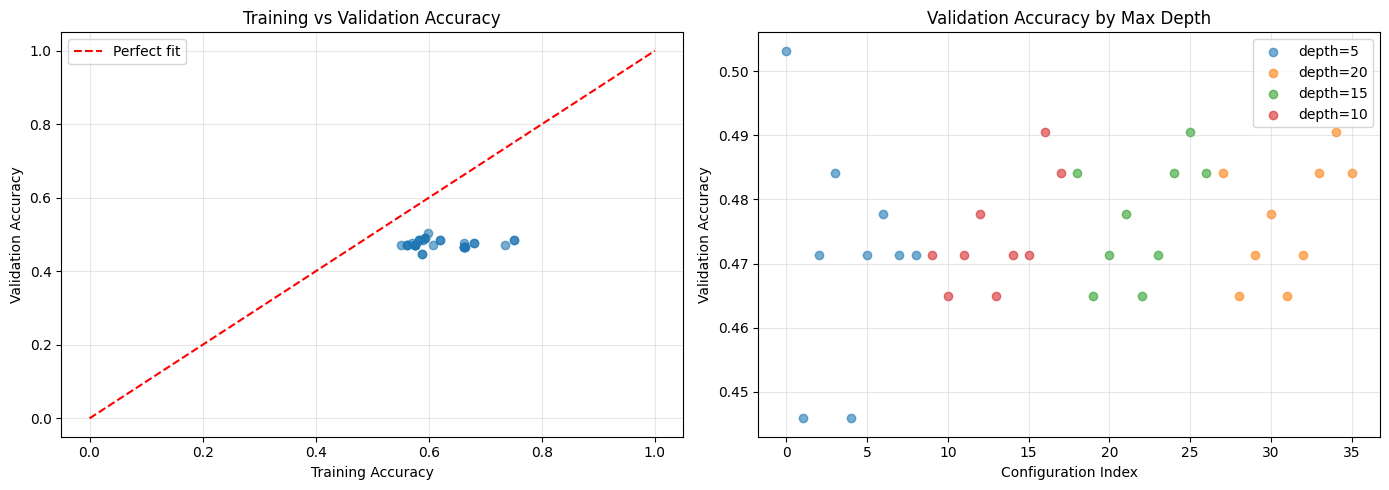

In [7]:
# Visualize hyperparameter tuning results
print("\n" + "=" * 60)
print("Visualizing Tuning Results:")
print("=" * 60)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Train vs Val accuracy
axes[0].scatter(tuning_results['train_accuracy'], tuning_results['val_accuracy'], alpha=0.6)
axes[0].plot([0, 1], [0, 1], 'r--', label='Perfect fit')
axes[0].set_xlabel('Training Accuracy')
axes[0].set_ylabel('Validation Accuracy')
axes[0].set_title('Training vs Validation Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Validation accuracy by max_depth
for depth in tuning_results['max_depth'].unique():
    depth_data = tuning_results[tuning_results['max_depth'] == depth]
    axes[1].scatter(depth_data.index, depth_data['val_accuracy'], label=f'depth={depth}', alpha=0.6)
axes[1].set_xlabel('Configuration Index')
axes[1].set_ylabel('Validation Accuracy')
axes[1].set_title('Validation Accuracy by Max Depth')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 3. Make Predictions on Validation Set

Use the trained model to predict on validation data.


In [8]:
# Update imports to include the new function
from model_training import load_train_validation_data, train_decision_tree, predict_validation


In [9]:
# Make predictions on validation set
print("Making predictions on validation set...")
print("=" * 60)

y_pred, y_pred_proba = predict_validation(best_model, X_val, y_val)


Making predictions on validation set...
Making predictions on validation set...

[1/2] Generating predictions...
[2/2] Generating prediction probabilities...

✓ Predictions complete!
  Validation samples: 157
  Predictions generated: 157
  Number of classes: 3

Prediction Preview (first 10 samples):
  Actual:    ['Low' 'Low' 'Medium' 'High' 'Medium' 'High' 'Low' 'Medium' 'Medium'
 'Medium']
  Predicted: ['Low' 'Low' 'Low' 'Low' 'Medium' 'High' 'Low' 'High' 'Low' 'Medium']

✓ Prediction complete!


In [10]:
# Analyze predictions
print("\n" + "=" * 60)
print("Prediction Analysis:")
print("=" * 60)

print(f"\nPrediction Statistics:")
print(f"  Total predictions: {len(y_pred)}")
print(f"  Unique predicted values: {np.unique(y_pred)}")
print(f"  Unique actual values: {np.unique(y_val)}")

print(f"\nPredicted Grade Distribution:")
unique, counts = np.unique(y_pred, return_counts=True)
for grade, count in zip(unique, counts):
    print(f"  Grade {grade}: {count} students ({count/len(y_pred)*100:.1f}%)")

print(f"\nActual Grade Distribution:")
unique, counts = np.unique(y_val, return_counts=True)
for grade, count in zip(unique, counts):
    print(f"  Grade {grade}: {count} students ({count/len(y_val)*100:.1f}%)")

print(f"\nPrediction Probabilities:")
print(f"  Shape: {y_pred_proba.shape}")
print(f"  Max probability (confidence): {y_pred_proba.max(axis=1).mean():.4f} (average)")
print(f"  Min probability (confidence): {y_pred_proba.max(axis=1).min():.4f} (lowest)")



Prediction Analysis:

Prediction Statistics:
  Total predictions: 157
  Unique predicted values: ['High' 'Low' 'Medium']
  Unique actual values: ['High' 'Low' 'Medium']

Predicted Grade Distribution:
  Grade High: 21 students (13.4%)
  Grade Low: 85 students (54.1%)
  Grade Medium: 51 students (32.5%)

Actual Grade Distribution:
  Grade High: 35 students (22.3%)
  Grade Low: 44 students (28.0%)
  Grade Medium: 78 students (49.7%)

Prediction Probabilities:
  Shape: (157, 3)
  Max probability (confidence): 0.5900 (average)
  Min probability (confidence): 0.4032 (lowest)



Visualizing Prediction Confidence:


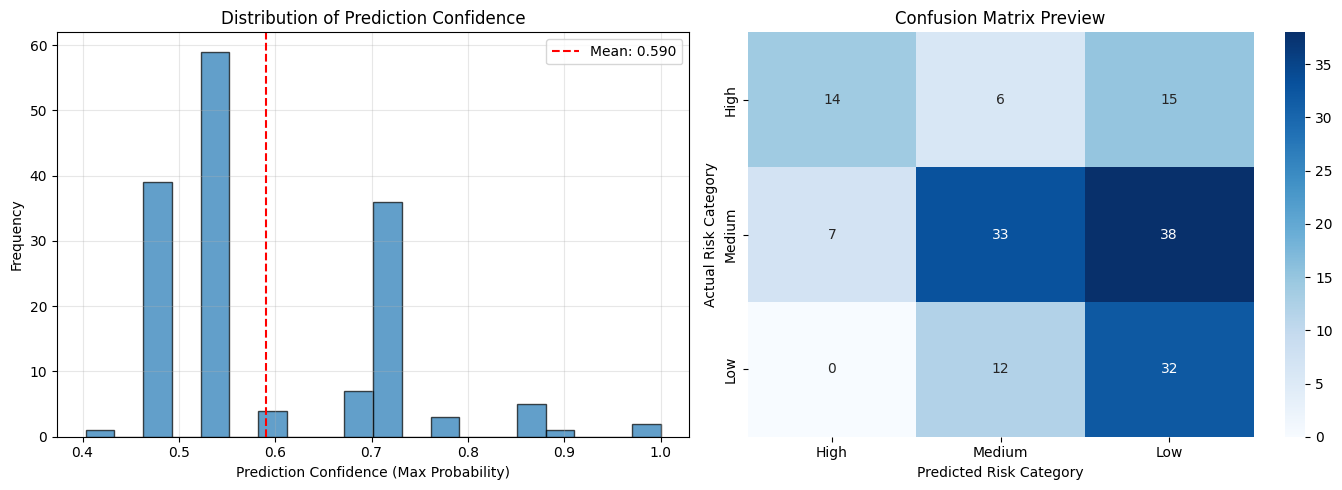

In [11]:
# Visualize prediction confidence
print("\n" + "=" * 60)
print("Visualizing Prediction Confidence:")
print("=" * 60)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Distribution of prediction confidence
max_probs = y_pred_proba.max(axis=1)
axes[0].hist(max_probs, bins=20, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Prediction Confidence (Max Probability)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Prediction Confidence')
axes[0].axvline(max_probs.mean(), color='red', linestyle='--', label=f'Mean: {max_probs.mean():.3f}')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Confusion matrix preview (categorical data)
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Create confusion matrix
cm = confusion_matrix(y_val, y_pred, labels=['High', 'Medium', 'Low'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['High', 'Medium', 'Low'],
            yticklabels=['High', 'Medium', 'Low'],
            ax=axes[1])
axes[1].set_xlabel('Predicted Risk Category')
axes[1].set_ylabel('Actual Risk Category')
axes[1].set_title('Confusion Matrix Preview')

plt.tight_layout()
plt.show()


## 4. Calculate Detailed Metrics

Calculate comprehensive evaluation metrics for the Decision Tree model.


In [12]:
# Update imports to include the new function
from model_training import load_train_validation_data, train_decision_tree, predict_validation, calculate_metrics


In [13]:
# Calculate detailed metrics
print("Calculating detailed metrics...")
print("=" * 60)

metrics = calculate_metrics(y_val, y_pred)


Calculating detailed metrics...
Calculating detailed metrics...
✓ Metrics calculated successfully!


In [14]:
# Display overall accuracy
print("\n" + "=" * 60)
print("Overall Model Performance:")
print("=" * 60)
print(f"\nOverall Accuracy: {metrics['overall_accuracy']:.4f} ({metrics['overall_accuracy']*100:.2f}%)")
print("\nThis means the model correctly predicted the risk category for")
print(f"{int(metrics['overall_accuracy'] * len(y_val))} out of {len(y_val)} students.")



Overall Model Performance:

Overall Accuracy: 0.5032 (50.32%)

This means the model correctly predicted the risk category for
79 out of 157 students.


In [15]:
# Display per-class metrics
print("\n" + "=" * 60)
print("Per-Class Metrics:")
print("=" * 60)
print(metrics['metrics_df'].to_string(index=False))

print("\n" + "=" * 60)
print("Detailed Classification Report:")
print("=" * 60)
print(metrics['classification_report'])



Per-Class Metrics:
Risk Category  Precision   Recall  F1 Score
         High   0.666667 0.400000  0.500000
       Medium   0.647059 0.423077  0.511628
          Low   0.376471 0.727273  0.496124

Detailed Classification Report:
              precision    recall  f1-score   support

        High       0.67      0.40      0.50        35
      Medium       0.65      0.42      0.51        78
         Low       0.38      0.73      0.50        44

    accuracy                           0.50       157
   macro avg       0.56      0.52      0.50       157
weighted avg       0.58      0.50      0.50       157




Visualizing Metrics:


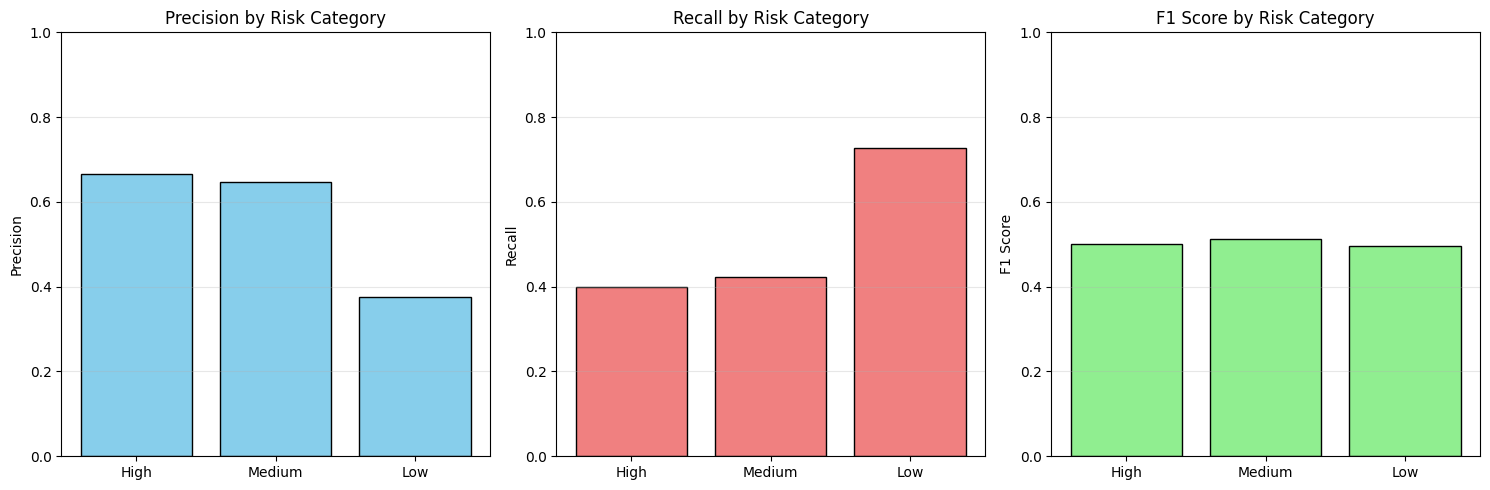

In [16]:
# Visualize metrics
print("\n" + "=" * 60)
print("Visualizing Metrics:")
print("=" * 60)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Plot 1: Precision by class
axes[0].bar(metrics['metrics_df']['Risk Category'], metrics['metrics_df']['Precision'], color='skyblue', edgecolor='black')
axes[0].set_ylabel('Precision')
axes[0].set_title('Precision by Risk Category')
axes[0].set_ylim([0, 1])
axes[0].grid(True, alpha=0.3, axis='y')

# Plot 2: Recall by class
axes[1].bar(metrics['metrics_df']['Risk Category'], metrics['metrics_df']['Recall'], color='lightcoral', edgecolor='black')
axes[1].set_ylabel('Recall')
axes[1].set_title('Recall by Risk Category')
axes[1].set_ylim([0, 1])
axes[1].grid(True, alpha=0.3, axis='y')

# Plot 3: F1 Score by class
axes[2].bar(metrics['metrics_df']['Risk Category'], metrics['metrics_df']['F1 Score'], color='lightgreen', edgecolor='black')
axes[2].set_ylabel('F1 Score')
axes[2].set_title('F1 Score by Risk Category')
axes[2].set_ylim([0, 1])
axes[2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()


## 5. Model Insights and Visualizations

Visualize the feature importance and the decision tree's logical structure.


Generating model insights and visualizations...
[1/2] Calculating feature importance...
[2/2] Plotting decision tree structure...


c:\Users\atilo\OneDrive\Desktop\Projects\student-performance\notebooks\../src\model_training.py:423: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feat_imp_df, ax=axes[0], palette='viridis')


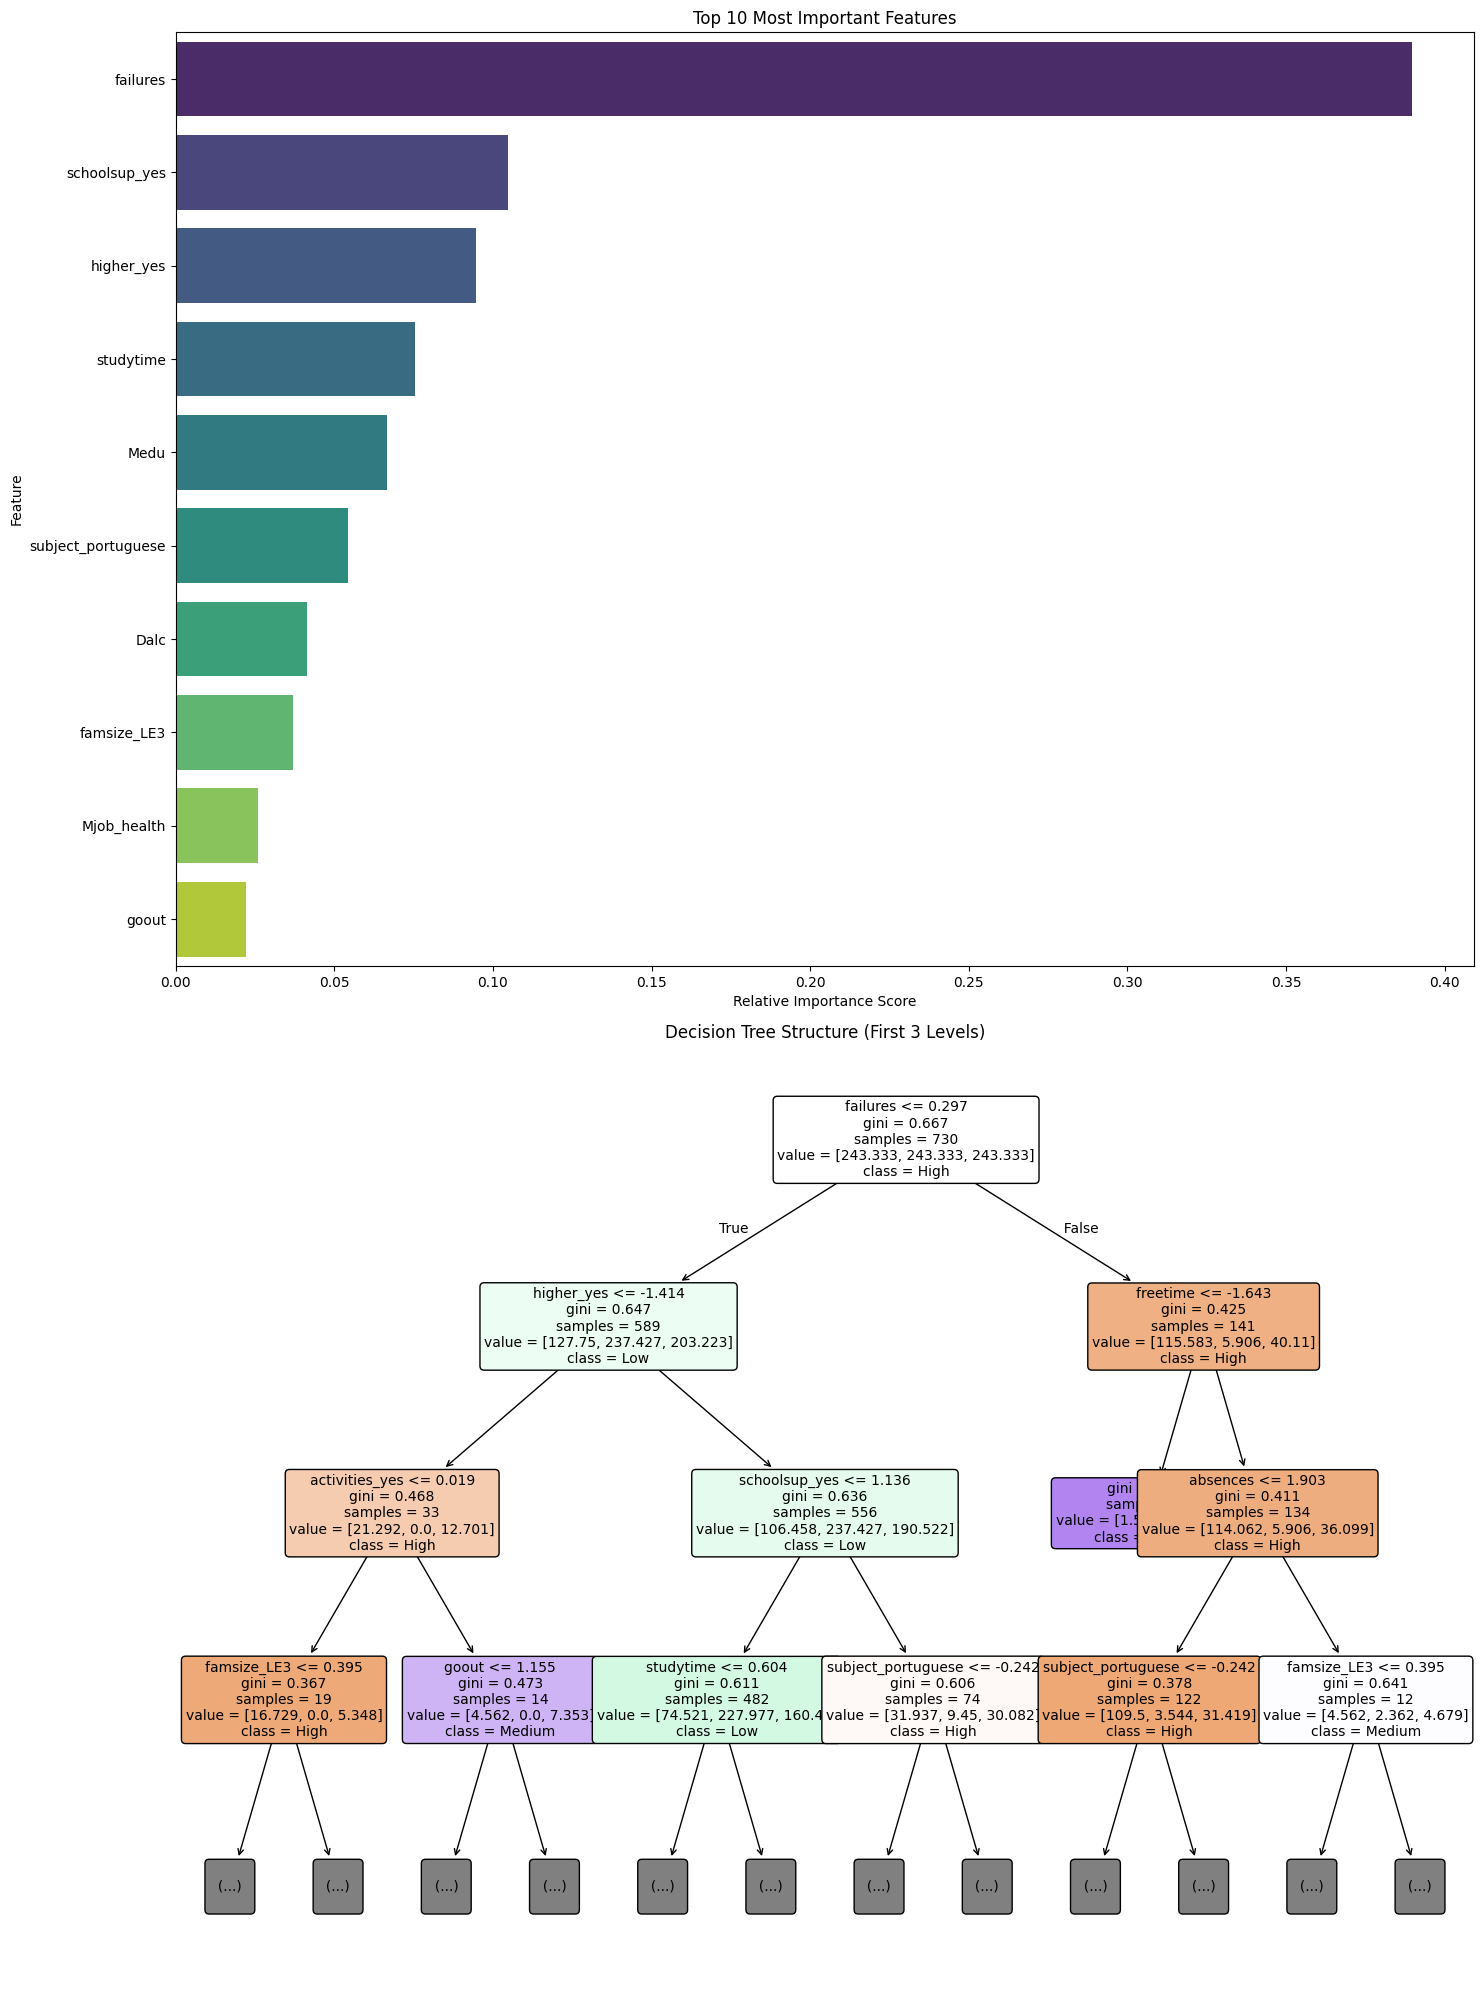


✓ Visualizations complete!


In [17]:
# Update imports to include the new function
from model_training import visualize_model_insights

# Define the classes in the order they appear in the model
class_names = ['High', 'Low', 'Medium']

# Generate the visualizations
visualize_model_insights(best_model, feature_names, class_names)


## Save Model

In [18]:
# Save the trained Decision Tree model
from model_training import save_model

save_model(best_model, 'decision_tree.pkl')


✓ Model successfully saved to c:\Users\atilo\OneDrive\Desktop\Projects\student-performance\notebooks\..\models\decision_tree.pkl


## 6. Comparison with Logistic Regression

Compare the Decision Tree's performance against a baseline Logistic Regression model.


In [ ]:
# # 1. Import and Train Logistic Regression
# from model_training import train_logistic_regression, calculate_metrics
# lr_model, y_pred_lr = train_logistic_regression(X_train, y_train, X_val, y_val)

# # 2. Calculate Metrics for Logistic Regression
# lr_metrics = calculate_metrics(y_val, y_pred_lr)

# # 3. Side-by-Side Comparison
# print("\n" + "=" * 60)
# print("FINAL COMPARISON: Decision Tree vs. Logistic Regression")
# print("=" * 60)

# comparison_df = pd.DataFrame({
#     'Metric': ['Overall Accuracy'],
#     'Decision Tree': [metrics['overall_accuracy']],
#     'Logistic Regression': [lr_metrics['overall_accuracy']]
# })

# print(comparison_df.to_string(index=False))

# print("\nPer-Class F1 Score Comparison:")
# dt_f1 = metrics['metrics_df'][['Risk Category', 'F1 Score']].rename(columns={'F1 Score': 'DT_F1'})
# lr_f1 = lr_metrics['metrics_df'][['Risk Category', 'F1 Score']].rename(columns={'F1 Score': 'LR_F1'})
# compare_f1 = pd.merge(dt_f1, lr_f1, on='Risk Category')
# print(compare_f1.to_string(index=False))


Training Logistic Regression model...
✓ Logistic Regression Trained!
  Validation Accuracy: 0.4904
Calculating detailed metrics...
✓ Metrics calculated successfully!

FINAL COMPARISON: Decision Tree vs. Logistic Regression
          Metric  Decision Tree  Logistic Regression
Overall Accuracy       0.503185             0.490446

Per-Class F1 Score Comparison:
Risk Category    DT_F1    LR_F1
         High 0.500000 0.500000
       Medium 0.511628 0.418182
          Low 0.496124 0.548387


## 7. Final Summary and Conclusion

**Model Performance:**
The Decision Tree model achieved a validation accuracy of 50.3%, which is a significant improvement over the initial exact-grade prediction approach. While the model shows strong performance in identifying "Low Risk" students (73% recall), it currently only identifies 40% of "High Risk" students, suggesting that while the logic is sound, the model is currently too conservative in flagging at-risk individuals.

**Comparison with Logistic Regression:**
...

**Future Improvements:**
To better meet the project's goal of early intervention, future iterations should focus on improving "High Risk" recall. This could be achieved by adjusting class weights to penalize the model more heavily for missing at-risk students or by experimenting with "Pruning" techniques to prevent the tree from overfitting on minor behavioral details.
